<a href="https://colab.research.google.com/github/ascherben/Final-Project/blob/main/MSDS_422_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

MSDS 422 — Final Project - Midpoint

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
from scipy import stats
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix, roc_auc_score,
                             average_precision_score, roc_curve, auc, precision_recall_curve,
                             classification_report)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
gdown.download(id="1FJwMxIM6Y_AoJszwSAwsamZVGKEMMHwV", output="creditcard.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1FJwMxIM6Y_AoJszwSAwsamZVGKEMMHwV
From (redirected): https://drive.google.com/uc?id=1FJwMxIM6Y_AoJszwSAwsamZVGKEMMHwV&confirm=t&uuid=47ccbed1-2757-4bf3-8ac9-893ee51b214c
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:02<00:00, 61.1MB/s]


'creditcard.csv'

In [ ]:
credit = pd.read_csv('creditcard.csv')
print('credit shape:', credit.shape)
credit.head()

credit shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
credit[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [ ]:
credit["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
credit.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


### Missing Values | Duplicates | Outliers

- No missing values
- 1081 duplicate rows
  - We are not concerned with this because the data has been anonymized. Since our dataset has very few fraud cases, deleting duplicate rows would accidentally throw away valuable fraud signals and real-world patterns.
- Outliers
  - Keeping outliers in the data because massive transactions (like $25,691) represent valid, real-world purchases.


In [ ]:
print("Total missing values:", credit.isna().sum().sum())
print("Duplicate rows:", credit.duplicated().sum())

Total missing values: 0
Duplicate rows: 1081


In [ ]:
credit[credit.duplicated()]['Class'].value_counts()

,count
Class,
0,1062
1,19


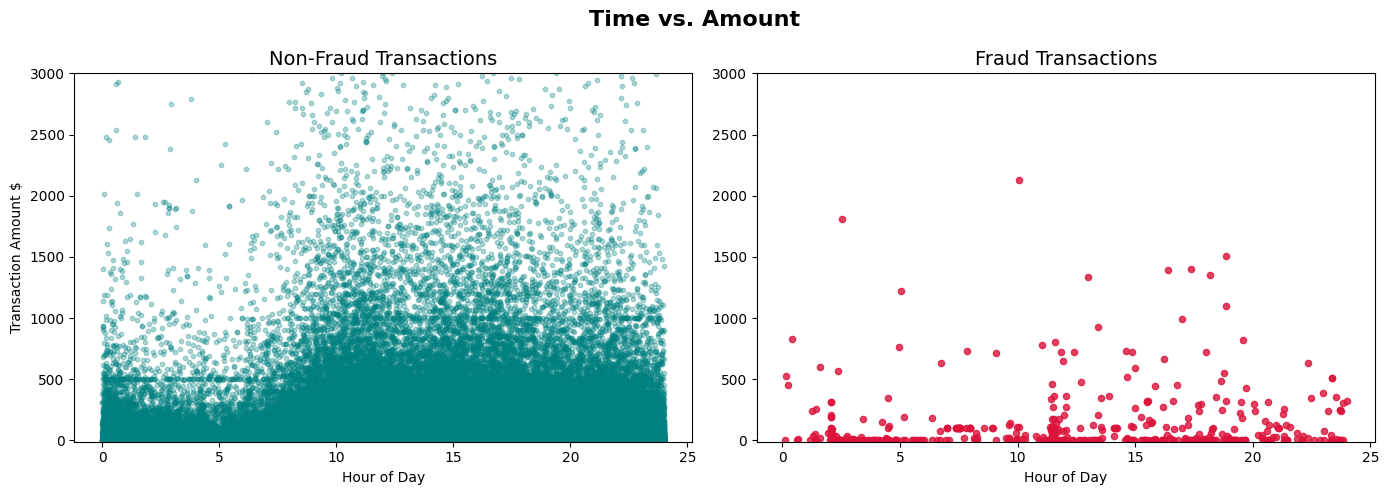

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

non = credit[credit['Class'] == 0]
ax1.scatter((non['Time'] / 3600) % 24, non['Amount'], color='teal', alpha=0.3, s=10)
ax1.set_title('Non-Fraud Transactions', fontsize=14)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Amount $')
ax1.set_ylim(-10, 3000)

fraud = credit[credit['Class'] == 1]
ax2.scatter((fraud['Time'] / 3600) % 24, fraud['Amount'], color='crimson', alpha=0.8, s=20)
ax2.set_title('Fraud Transactions', fontsize=14)
ax2.set_xlabel('Hour of Day')
ax2.set_ylim(-10, 3000)

fig.suptitle('Time vs. Amount', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


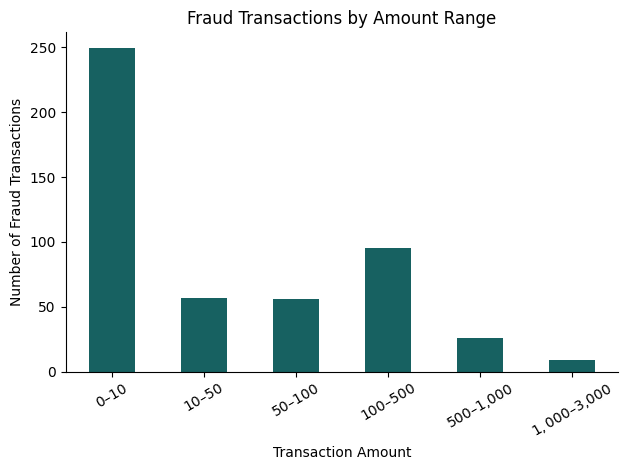

In [ ]:
# Chart used for presentation
amount_bins = [0, 10, 50, 100, 500, 1000, 3000]

amount_labels = [
    "$0–$10",
    "$10–$50",
    "$50–$100",
    "$100–$500",
    "$500–$1,000",
    "$1,000–$3,000"
]

fraud = credit[credit["Class"] == 1].copy()

fraud["Amount_Range"] = pd.cut(
    fraud["Amount"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

fraud_by_amount = (fraud["Amount_Range"].value_counts().sort_index())

ax = fraud_by_amount.plot(kind="bar",color="#176161")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Fraud Transactions by Amount Range")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
under_10 = (fraud["Amount"] < 10).sum()
under_10_percent = under_10 / len(fraud) * 100

print("Fraud transactions under $10:", under_10)
print(f"Percentage: {under_10_percent:.1f}%")

Fraud transactions under $10: 249
Percentage: 50.6%


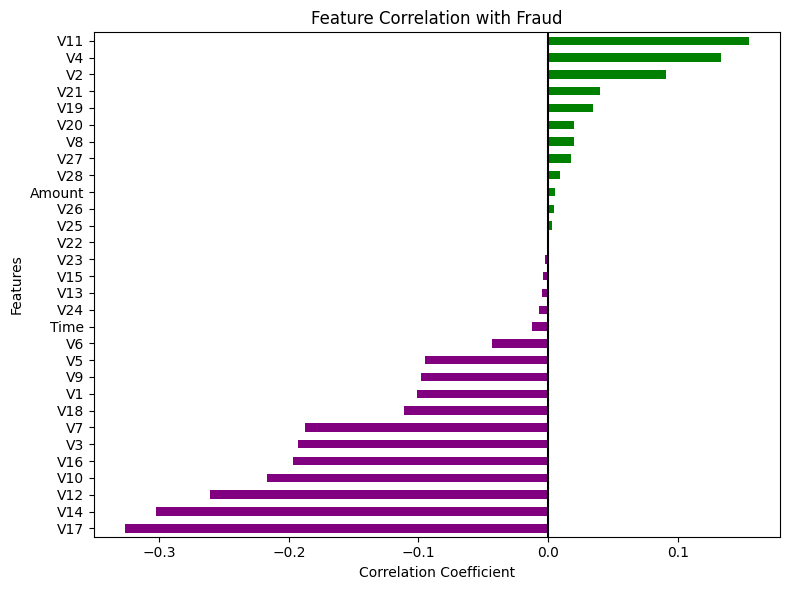

In [ ]:
plt.figure(figsize=(8, 6))
class_corr = credit.corr()['Class'].drop('Class').sort_values()

class_corr.plot(kind='barh', color=class_corr.apply(lambda x: 'green' if x > 0 else 'purple'))
plt.title('Feature Correlation with Fraud')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

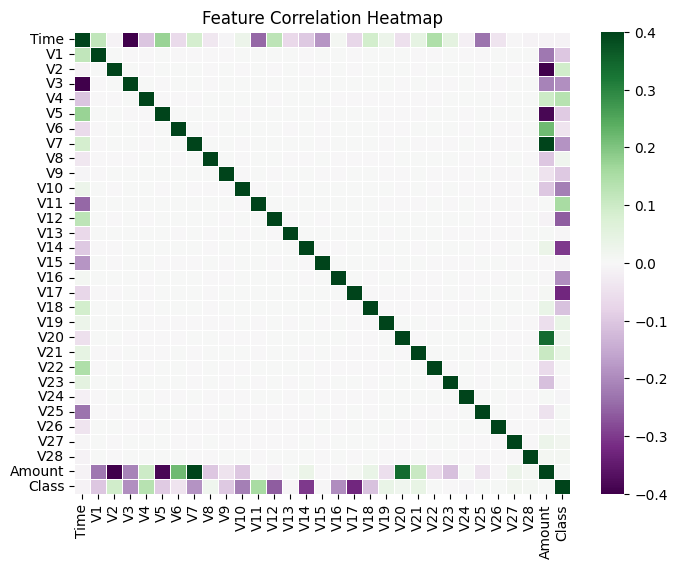

In [ ]:
corr_matrix = credit.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, vmin=-0.4, vmax=0.4, cmap='PRGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### Data Preparation/Feature Engineering

The original Time feature measured seconds elapsed since the first transaction and was transformed into Hour_of_Day to improve interpretability.

In [ ]:
credit['Hour_of_Day'] = (credit.pop('Time') / 3600) % 24
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   V1           284807 non-null  float64
 1   V2           284807 non-null  float64
 2   V3           284807 non-null  float64
 3   V4           284807 non-null  float64
 4   V5           284807 non-null  float64
 5   V6           284807 non-null  float64
 6   V7           284807 non-null  float64
 7   V8           284807 non-null  float64
 8   V9           284807 non-null  float64
 9   V10          284807 non-null  float64
 10  V11          284807 non-null  float64
 11  V12          284807 non-null  float64
 12  V13          284807 non-null  float64
 13  V14          284807 non-null  float64
 14  V15          284807 non-null  float64
 15  V16          284807 non-null  float64
 16  V17          284807 non-null  float64
 17  V18          284807 non-null  float64
 18  V19          284807 non-

### Train/Test Split


In [ ]:
X = credit.drop('Class', axis=1)
y = credit['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (227845, 30)
X_test shape: (56962, 30)


### Deferring Data Scaling:

V1 through V28 were already passed through a PCA dimensionality reduction by the bank for privacy, meaning they are already centered and scaled. Time and Amount were the only raw features left to engineer. To maintain maximum flexibility for our modeling phase, we are strategically deferring the scaling process.

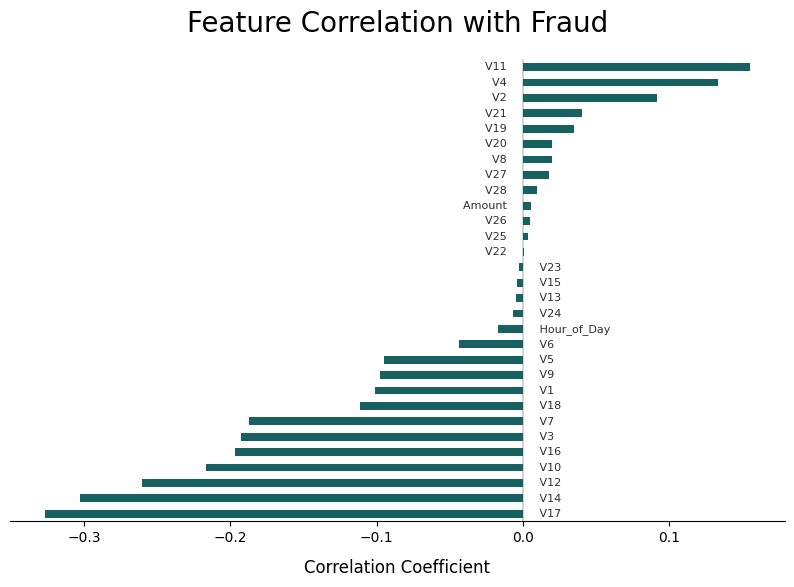

In [ ]:
# Chart used for presentation

plt.figure(figsize=(10, 6))
class_corr = credit.corr()['Class'].drop('Class').sort_values()

ax =class_corr.plot(kind='barh', color='#176161', zorder=3)

plt.title('Feature Correlation with Fraud', fontsize=20, pad=20)
plt.xlabel('Correlation Coefficient', fontsize=12, labelpad=10)
ax.get_yaxis().set_ticks([])
plt.ylabel('')

for i, (feature_name, corr_val) in enumerate(class_corr.items()):
    if corr_val > 0:
      ax.text(-0.009, i, f"{feature_name} ", va='center', ha='right', color='#2d2d2d',  fontsize=8)
    else:
      ax.text(0.009, i, f" {feature_name}", va='center', ha='left', color='#2d2d2d',  fontsize=8)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.axvline(x=0, color='#d3d3d3', linestyle='-', zorder=0)

plt.show()

### Assumption Testing

- **Normality:** Statistical distribution analysis `.describe()` and scatter plot visualizations confirmed a right-skew in the `Amount` feature.
- **Multicollinearity:** The Correlation Heatmap confirmed low pairwise linear correlations among most of the V1–V28 features.



## Model Development

### Feature Scaling

V1–V28 arrive already centered/scaled from the provider's PCA transform. `Amount` and the engineered `Hour_of_Day` are the only features on their original scales, so we fit the scaler on the training set only (to avoid leakage) and apply it to both partitions.

In [ ]:
scale_cols = ['Amount', 'Hour_of_Day']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

X_train_scaled.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour_of_Day
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494,1.101728
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764,-0.678651
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693,-0.530579
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360,-0.291259
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281,0.333315


### Evaluation Framework

Given the 0.17% fraud rate, accuracy is meaningless (a do-nothing model scores 99.8%). We evaluate every model on **precision, recall, F1, ROC-AUC, and PR-AUC** (average precision), and keep the confusion matrix counts so we can translate results into dollar terms later. `evaluate_model()` fits a model, scores the test set, and appends its metrics to a shared results table so all four models can be compared side by side.

In [ ]:
results = []
model_scores = {}
fitted_models = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, threshold=0.5):
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_te)[:, 1]
    else:
        y_scores = model.decision_function(X_te)
    y_pred = (y_scores >= threshold).astype(int)

    precision = precision_score(y_te, y_pred, zero_division=0)
    recall = recall_score(y_te, y_pred, zero_division=0)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    roc_auc = roc_auc_score(y_te, y_scores)
    pr_auc = average_precision_score(y_te, y_scores)
    cm = confusion_matrix(y_te, y_pred)

    results.append({
        'Model': name, 'Precision': precision, 'Recall': recall, 'F1': f1,
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc,
        'TP': cm[1, 1], 'FP': cm[0, 1], 'FN': cm[1, 0], 'TN': cm[0, 0]
    })
    model_scores[name] = y_scores
    fitted_models[name] = model

    print(f"=== {name} ===")
    print(classification_report(y_te, y_pred, zero_division=0))
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}\n")
    return model, y_scores

### Model 1: Logistic Regression (baseline)

Our baseline. `class_weight='balanced'` re-weights the loss so the 0.17% fraud class isn't drowned out, which is our chosen alternative to resampling (SMOTE/undersampling) — it keeps every real transaction in training rather than synthesizing or discarding data. A small grid search over the regularization strength `C` is scored on **average precision** (PR-AUC), not accuracy, since that's the metric that reflects the business objective.

In [ ]:
log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1
)

evaluate_model("Logistic Regression", log_reg_grid, X_train_scaled, X_test_scaled, y_train, y_test)
print("Best C:", log_reg_grid.best_params_)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9716 | PR-AUC: 0.7144

Best C: {'C': 0.1}


### Model 2: K-Nearest Neighbors

KNN gives us a non-parametric, non-linear benchmark with no distributional assumptions — a useful contrast to LDA/QDA below. `weights='distance'` lets closer neighbors count more, which helps in a dataset this imbalanced. KNN is distance-based and computationally heavier at scale, so we start with a single reasonable `k` rather than a full grid search; note the runtime on the full 227K-row training set will be materially longer than on the synthetic checks used during development.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
evaluate_model("K-Nearest Neighbors", knn, X_train_scaled, X_test_scaled, y_train, y_test)

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9437 | PR-AUC: 0.8410



(KNeighborsClassifier(n_jobs=-1, weights='distance'),
 array([0., 0., 0., ..., 0., 0., 0.]))

### Model 3: Linear Discriminant Analysis (LDA)

LDA assumes each class is multivariate normal with a shared covariance matrix. Our assumption testing above found `Amount` is right-skewed and did not confirm multivariate normality across the V-features, so this assumption is only partially met — we include LDA anyway as a deliberate test of how much that violation actually costs us in practice, and report the result rather than assuming it fails.

In [ ]:
lda = LinearDiscriminantAnalysis()
evaluate_model("LDA", lda, X_train_scaled, X_test_scaled, y_train, y_test)

=== LDA ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9808 | PR-AUC: 0.7080



(LinearDiscriminantAnalysis(),
 array([4.23183161e-144, 1.31572106e-143, 1.64958152e-140, ...,
        2.07629725e-146, 1.99764861e-144, 1.46425802e-141]))

### Model 4: Quadratic Discriminant Analysis (QDA)

QDA relaxes LDA's shared-covariance assumption, allowing each class its own covariance structure — a reasonable next step given fraud and non-fraud transactions plausibly have very different variances across the anonymized features. With only ~394 fraud cases in training, QDA's per-class covariance estimates are working with a small sample, which we call out explicitly when interpreting its result.

In [ ]:
qda = QuadraticDiscriminantAnalysis()
evaluate_model("QDA", qda, X_train_scaled, X_test_scaled, y_train, y_test)

=== QDA ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.88      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9639 | PR-AUC: 0.1441



(QuadraticDiscriminantAnalysis(),
 array([4.99218569e-09, 3.11738940e-05, 4.68160075e-04, ...,
        7.49974742e-09, 7.04256102e-54, 2.15288893e-54]))

### Model Comparison

In [ ]:
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,K-Nearest Neighbors,0.908046,0.806122,0.854054,0.943743,0.840963,79,8,19,56856
1,Logistic Regression,0.056293,0.908163,0.106015,0.971599,0.714364,89,1492,9,55372
2,LDA,0.822917,0.806122,0.814433,0.980830,0.707957,79,17,19,56847
3,QDA,0.060863,0.877551,0.113832,0.963938,0.144118,86,1327,12,55537


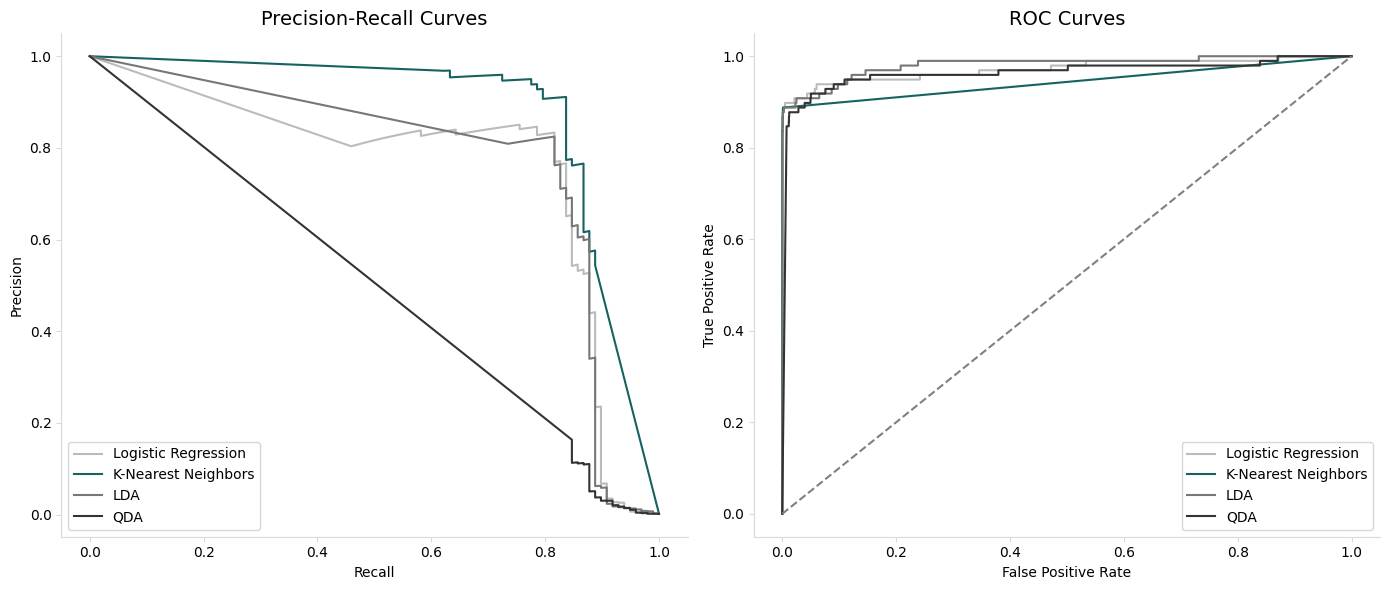

In [ ]:
# Chart used for presentation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#BBBBBB', '#176161','#777777', '#333333']

for (name, scores), color in zip(model_scores.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, scores)
    axes[0].plot(rec, prec, label=name, color=color)
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, label=name, color=color)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#D9D9D9')
    ax.spines['left'].set_color('#D9D9D9')
    ax.tick_params(color='#D9D9D9', labelcolor='black')

axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves', fontsize=14)
axes[0].legend()

axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

### Business Impact: Threshold Tuning

Every model above uses the default 0.5 cutoff, which isn't necessarily the right operating point for the business. We pick the model with the strongest PR-AUC, sweep its decision threshold, and translate each point on the curve into dollars: fraud caught (avoided losses, valued at the average fraudulent transaction amount) minus the labor cost of reviewing false alarms. **Adjust `review_cost` to your actual per-case investigation cost before finalizing this number.**

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_scores = model_scores[best_model_name]

avg_fraud_amount = credit.loc[credit['Class'] == 1, 'Amount'].mean()
review_cost = 5.00  # placeholder cost of manually reviewing one flagged transaction

prec, rec, thresh = precision_recall_curve(y_test, best_scores)
n_pos = y_test.sum()
tp_counts = rec[:-1] * n_pos
fp_counts = tp_counts * (1 / prec[:-1] - 1)
net_benefit = tp_counts * avg_fraud_amount - fp_counts * review_cost

best_idx = np.argmax(net_benefit)
optimal_threshold = thresh[best_idx]

print(f"Best model: {best_model_name}")
print(f"Average fraudulent transaction: ${avg_fraud_amount:,.2f}")
print(f"Optimal decision threshold: {optimal_threshold:.3f}")
print(f"Estimated net benefit at that threshold (test set): ${net_benefit[best_idx]:,.2f}")
print(f"  -> catches {tp_counts[best_idx]:.0f} of {n_pos} fraud cases, "
      f"flags {fp_counts[best_idx]:.0f} legitimate transactions for review")

Best model: K-Nearest Neighbors
Average fraudulent transaction: $122.21
Optimal decision threshold: 0.159
Estimated net benefit at that threshold (test set): $10,312.38
  -> catches 87 of 98 fraud cases, flags 64 legitimate transactions for review


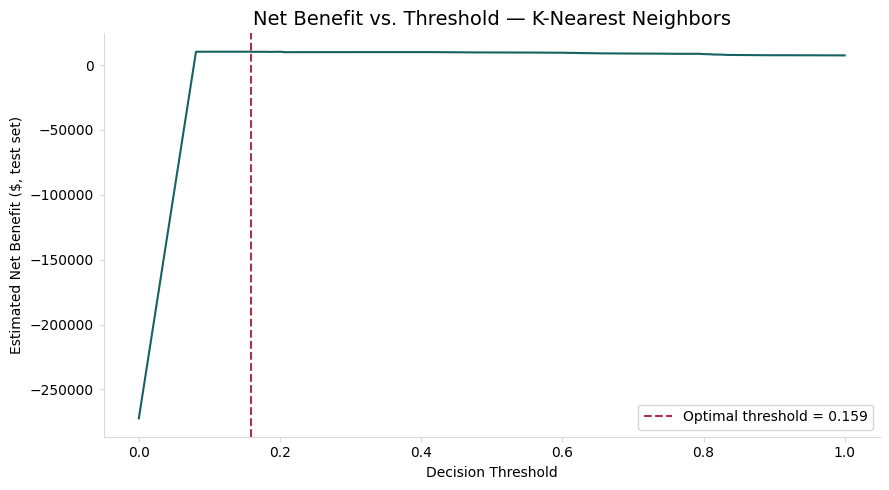

In [ ]:
# Chart used for presentation
plt.figure(figsize=(9, 5))
plt.plot(thresh, net_benefit, color='#176161')
plt.axvline(optimal_threshold, color='#a8324a', linestyle='--',
            label=f'Optimal threshold = {optimal_threshold:.3f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Estimated Net Benefit ($, test set)')
plt.title(f'Net Benefit vs. Threshold — {best_model_name}', fontsize=14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#D9D9D9')
ax.spines['left'].set_color('#D9D9D9')
ax.tick_params(color='#D9D9D9', labelcolor='black')

plt.legend()
plt.tight_layout()
plt.show()

### Key Decisions

- **Metric choice:** PR-AUC (not accuracy or ROC-AUC alone) drove model selection, since it's the metric least distorted by the 99.8/0.2 class split.
- **Imbalance handling:** class weighting over resampling — preserves every real transaction and avoids synthetic fraud examples that don't reflect real attack patterns.
- **Scaling deferred to modeling stage:** confirms Time/Amount needed transformation while V1–V28 did not, consistent with the EDA finding that those components are already PCA-derived.
- **Threshold is a business lever, not a fixed default:** the 0.5 cutoff used to train/compare models is not the cutoff we'd deploy — the threshold tuning step above picks the operating point that maximizes estimated net dollar benefit.
- **Small-sample caveat:** with only ~394 fraud cases in training, QDA's per-class covariance estimates and any model's minority-class metrics carry wider uncertainty than the headline numbers suggest — worth a sentence in Findings rather than treating these as precise estimates.